# Helper Functions

In [2]:
import matplotlib.pyplot as plt
import time

# Displays state and information
def display_state(disp_state, disp_cluster, save=False):
    # setup
    print(f'Total sum of graph: {sum(sum(disp_state))}')
    fig, ax = plt.subplots(figsize=(4, 3))
    
    # Get prob heatmap
    im = ax.imshow(disp_state, cmap='YlOrRd', interpolation='nearest')
    plt.colorbar(im)

    # Overlay cluster cells in different color
    cluster_mask = np.zeros_like(disp_state, dtype=float)
    for r, c in disp_cluster:
        cluster_mask[r, c] = 1

    cluster_only = np.ma.masked_where(cluster_mask == 0, cluster_mask)
    ax.imshow(cluster_only, cmap='Blues', interpolation='nearest', 
              vmin=0, vmax=1, alpha=1.0)

    ax.axis('off')
    plt.tight_layout()
    if save:
        plt.savefig(f'plots/plot_{time.time()}.png')
    plt.show()

# Loads a cluster generated by mocs_2/partb_dla repo
# TO MAKE A NEW CLUSTER:
# in mocs_2, activate mocs_venv, then check partb_dla repo instructions for generating .npz files
def load_cluster(N, path):
    file = np.load(path)
    positions = file["positions"]

    _cluster = []

    # Translate coords for numpy (move origin to top left)
    for (i,j) in positions:
        i = int(N//2 + i) % N
        j = int(N//2 + j) % N
        _cluster.append((i, j))

    return _cluster

# Von Neumann Neighborhood

In [ ]:
import numpy as np
from scipy.ndimage import convolve
from tqdm import tqdm
import matplotlib.pyplot as plt
import random
import math

# experimental setup

# This is from paper eqn. 12: /home/jack/school/mocs_2/dla_paper.pdf
def drop_walker(N, state):
    radius = N//2
    theta = random.uniform(0, 2 * math.pi)
    rand_i = math.floor(N//2 + radius*math.cos(theta))
    rand_j = math.floor(N//2 + radius*math.sin(theta))
    state[rand_i, rand_j] = 1

# init params
N = 80
state = np.zeros((N,N), dtype=float)
cluster = [(N//2, N//2)] # start w/ seed at center
drop_walker(N, state)

kernel = np.array([[0, 1/4, 0],
                   [1/4, 0, 1/4],
                   [0, 1/4, 0]])

# convlution steps
steps = 1_000_000

for step in tqdm(range(steps)):

    if len(cluster) > 600:
        break

    # update state
    state = convolve(state, kernel, mode='wrap', cval=0)

    # iterate over cluster THIS IS WHERE MOST OF THE TIME IS SPENT
    for (i, j) in cluster:
        
        # check every neighboring cell TODO: optimize finding adjcacent probs. THIS IS WHERE MOST OF THE TIME IS SPENT
        adj_coords = [((i-1) % N, j), ((i+1) % N, j), (i, (j-1) % N), (i, (j+1) % N)]
        for k, c in enumerate(adj_coords):
            p_coords = adj_coords[k] # get coords of neighbors
            p = state[c] # get prob from state

            if p != 0:
                
                # check if add to cluster (is walker there?)
                if random.uniform(0,1) < p:
                    # if yes, add to cluster
                    cluster.append(p_coords)
                    # reset
                    state = np.zeros((N,N), dtype=float)
                    drop_walker(N, state)
                else:
                    # make it zero
                    state[p_coords] = 0
                    # adjust probabilities accordingly (renormalize based on pmf removed)
                    state = state / (1-p)


# verify renormalization is working
#print(sum(sum(state)))

# ===== Display code =====
fig, ax = plt.subplots(figsize=(4, 3))

# Get prob heatmap
display = state.copy()
im = ax.imshow(display, cmap='YlOrRd', interpolation='nearest')
plt.colorbar(im)

# Overlay cluster cells in different color
cluster_mask = np.zeros_like(state, dtype=float)
for r, c in cluster:
    cluster_mask[r, c] = 1

cluster_only = np.ma.masked_where(cluster_mask == 0, cluster_mask)
ax.imshow(cluster_only, cmap='Blues', interpolation='nearest', 
          vmin=0, vmax=1, alpha=1.0)  # fully opaque = hides probs beneath

ax.axis('off')
plt.tight_layout()
plt.show()

# Moore Neighborhood

Cluster size 1:   0%|                                                                                                                                        | 0/1000000 [00:00<?, ?it/s]

Total sum of graph: 1.0


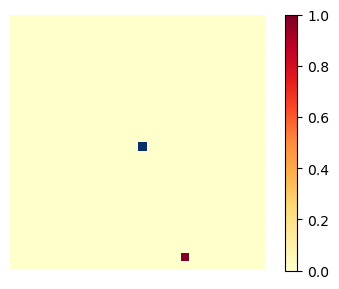

Cluster size 3:   0%|                                                                                                                             | 930/1000000 [00:01<22:42, 733.00it/s]

Total sum of graph: 1.0000000000000016


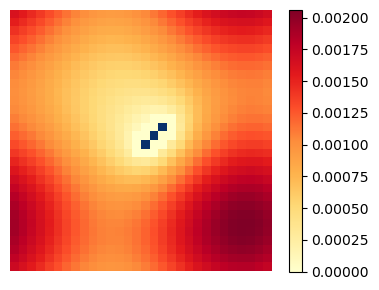

Cluster size 4:   0%|▏                                                                                                                           | 1973/1000000 [00:03<25:15, 658.34it/s]

Total sum of graph: 1.0000000000000335


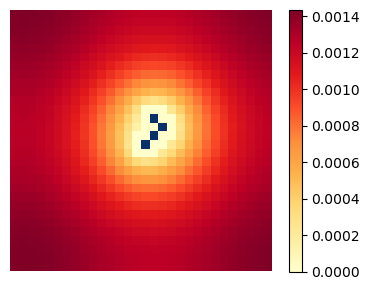

Cluster size 5:   0%|▎                                                                                                                           | 2964/1000000 [00:04<24:17, 684.16it/s]

Total sum of graph: 0.9999999999999992


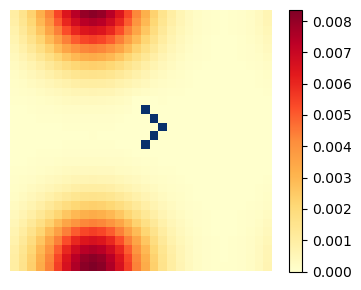

Cluster size 7:   0%|▍                                                                                                                           | 3963/1000000 [00:06<24:31, 677.10it/s]

Total sum of graph: 0.9999999999999982


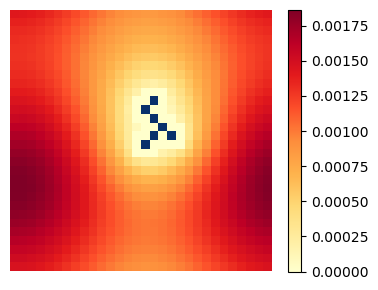

Cluster size 17:   0%|▌                                                                                                                          | 4998/1000000 [00:07<26:54, 616.13it/s]

Total sum of graph: 0.999999999999997


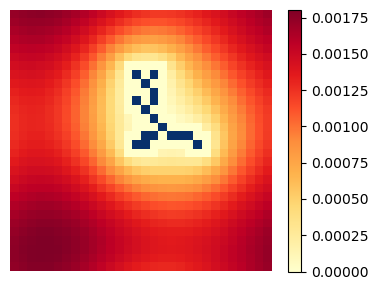

Cluster size 20:   1%|▋                                                                                                                          | 6000/1000000 [00:09<27:04, 612.00it/s]


Total sum of graph: 0.999999999999996


KeyboardInterrupt: 

<Figure size 400x300 with 0 Axes>

In [4]:
import numpy as np
from scipy.ndimage import convolve
from tqdm import tqdm
import matplotlib.pyplot as plt
import random
import math
import time

# This is from paper eqn. 12: /home/jack/school/mocs_2/dla_paper.pdf
# Spawns walkers on a radius
def drop_walker(N, state):
    radius = N//2
    theta = random.uniform(0, 2 * math.pi)
    rand_i = math.floor(N//2 + radius*math.cos(theta))
    rand_j = math.floor(N//2 + radius*math.sin(theta))
    state[rand_i, rand_j] = 1

# ============ params ============
N = 30
t_max = 1_000_000
state = np.zeros((N,N), dtype=float)

kernel = np.array([[1/8, 1/8, 1/8],
                   [1/8, 0, 1/8],
                   [1/8, 1/8, 1/8]])


# simulation setup
cluster = [(N//2, N//2)] # start w/ seed at center
for _ in range(1):
    drop_walker(N, state)

# using tqdm to display progress bar and info
p_bar = tqdm(range(t_max))
for step in p_bar:
    
    p_bar.set_description(f'Cluster size {len(cluster)}')
    if step % 1_000 == 0:
        display_state(state, cluster)
    
    # update state
    state = convolve(state, kernel, mode='wrap', cval=0)

    # iterate over cluster THIS IS WHERE MOST OF THE TIME IS SPENT
    for (i, j) in cluster:
        
        # check every neighboring cell TODO: optimize finding adjcacent probs. THIS IS WHERE MOST OF THE TIME IS SPENT
        #adj_coords = [((i-1) % N, j), ((i+1) % N, j), (i, (j-1) % N), (i, (j+1) % N)]
        adj_coords = [((i+di) % N, (j+dj) % N) for di in [-1,0,1] for dj in [-1,0,1] if not (di==0 and dj==0)]
        for k, c in enumerate(adj_coords):
            p_coords = adj_coords[k] # get coords of neighbors
            p = state[c] # get prob from state

            if p != 0:
                
                # check if add to cluster (is walker there?)
                if random.uniform(0,1) < p:
                    # if yes, add to cluster
                    cluster.append(p_coords)
                    # reset
                    state = np.zeros((N,N), dtype=float)
                    for _ in range(1):
                        drop_walker(N, state)
                else:
                    # make it zero
                    state[p_coords] = 0
                    # adjust probabilities accordingly (renormalize based on pmf removed)
                    state = state / (1-p)


display_state(state, cluster)
print(cluster)

# Hitting probabilities

1. convolve
2. Iterate over cluster perim
3. If prob touches cluster, freeze it, take it away from state and store it in perim list
4. set that cell in state to 0, keep convolving

Total state prob 100.000000:   0%|                                                                                                                            | 0/100000 [00:00<?, ?it/s]

Total sum of graph: 100.0


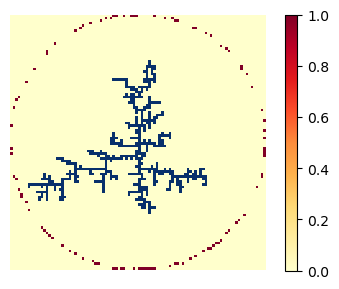

Total state prob 1.000465:   6%|██████▉                                                                                                           | 6067/100000 [00:30<07:54, 197.97it/s]


Total sum of graph: 1.0


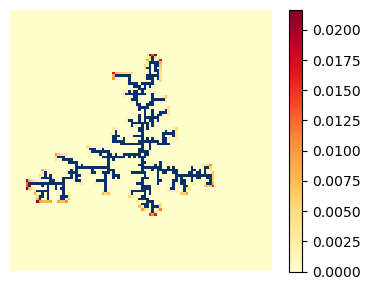

In [12]:
import numpy as np
from scipy.ndimage import convolve
from tqdm import tqdm
import random
import math

# This is from paper eqn. 12: /home/jack/school/mocs_2/dla_paper.pdf
# Spawns walkers on a radius
def drop_walker(N, state):
    radius = N//2
    while True:
        theta = random.uniform(0, 2 * math.pi)
        rand_i = math.floor(N//2 + radius*math.cos(theta))
        rand_j = math.floor(N//2 + radius*math.sin(theta))
        if state[rand_i, rand_j] == 0:
            state[rand_i, rand_j] = 1
            return

# Gets perimeter coords of cluster
def get_perim(cluster):
    perim = set()
    for (i, j) in cluster:
        neighbors = [((i + di) % N, (j + dj) % N) for di in [-1,0,1] for dj in [-1,0,1] if not (di==0 and dj==0)]
        for n in neighbors:
            perim.add(n)
    return perim

# ============ params ============
N = 100
num_walkers = 100
t_max = 100_000
state = np.zeros((N,N), dtype=float)
p_state = state.copy() # this will store our frozen perim probs

kernel = np.array([[1/8, 1/8, 1/8],
                   [1/8, 0, 1/8],
                   [1/8, 1/8, 1/8]])

# ============ init ============
cluster = load_cluster(N, "partb_dla/results/my_cluster.npz")
perimeter = get_perim(cluster)

for _ in range(num_walkers):
    drop_walker(N, state)
    
# using tqdm to display progress bar and info
p_bar = tqdm(range(t_max))
for step in p_bar:

    p_bar.set_description(f'Total state prob {sum(sum(state)):.6f}')
    if step % 100_000 == 0:
        display_state(state, cluster)
    
    # ================== MAIN LOOP ==================
    # update state
    state = convolve(state, kernel, mode='wrap', cval=0)
    
    # iterate over perimeter
    for (i, j) in perimeter:
        p = state[i, j]
        # if prob in perimeter (touching cluster)
        if p != 0:
            # Store in p_state, freezing it and adding it to correct cell
            p_state[i, j] += p
            # Remove mass from state
            state[i, j] = 0
    
        # If weve gathered more than the threshold of the pmf in the perimeter (here is 99%)
    if sum(sum(p_state)) > (0.99)*num_walkers:
        break

p_state = p_state / sum(sum(p_state))
display_state(p_state, cluster, save=True)

## TODO
- Convert to colab
- make off lattice version, importantly this version can do both brownian field and direct sim
- Get BCD dim working
- Compare cluster sizes as a function of time to see trajectory of each approach (for growing)
- for paper, esitmate harmonic boundary?
- Branch analysis, how to gather data about where a branch will be
  - Could be dependant on existing cluster
  - How do we pick a branch, first do that